# 02 - Train Spec2VolCAMU-Net: EEG -> fMRI

**Run this notebook on the PC with the GPU.** It needs only the `NODDI_h5` folder made by
notebook 01 - not the raw EEG / fMRI files, and not the GitHub repo.

| notebook | runs on | does |
|---|---|---|
| `01_Preprocess_EEG_fMRI_to_h5.ipynb` | the data PC, CPU only | raw scanner files -> training pairs in `.h5` files |
| **`02_Train_Spec2VolCAMU_Net.ipynb`** (this one) | **the GPU PC** | builds the model, trains it, evaluates it |

This is a notebook re-implementation of **Spec2VolCAMU-Net** (He et al., 2025, arXiv:2505.09521,
code: `github.com/hdy6438/Spec2VolCAMU-Net`). The model here was checked against the repo's own
code: same 455 weight tensors, same 45,927,230 parameters, same outputs and same gradients.

---

## What we are doing, in plain words

We have 4,384 question-and-answer cards. Each card says: *"here are the last 43 seconds of
EEG - now draw the brain scan that came next."*

Training is showing the model those cards over and over. Each time, it draws its guess, we
measure how wrong the drawing is, and we nudge the model's 46 million internal numbers so the
next guess is a little less wrong.

To test honestly, we hide **one whole person** from training. After training we ask the model to
draw that person's scans from their EEG alone. That is the score that counts.

```
  INPUT  (20, 64, 249)                                             OUTPUT  (30, 64, 64)
  20 EEG pictures, values 0-1                                      one fMRI volume, values 0-1
          |                                                                 ^
          v                                                                 |
  +---------------- ENCODER (1.3 M numbers) ----------------+   +---- DECODER (44.7 M numbers) ----+
  | mix the 20 pictures into 256 feature maps    64 x 249    |   |  Vision-Mamba U-Net             |
  | block 1: small filters + attention, halve    64 x 125    |-->|  64x64 -> 16 -> 8 -> 4 -> 2     |
  | block 2: small filters + attention, halve    64 x 63     |   |        -> 4 -> 8 -> 16 -> 64x64 |
  | pad to a square                               64 x 64    |   |  30 output maps = the 30 slices |
  +----------------------------------------------------------+   +---------------------------------+
```

## What you need on this PC

- an NVIDIA GPU. My estimate is that 12 GB of GPU memory is comfortable at the paper's batch
  size and 8 GB needs the batch size halved (Step 2 explains how). It is an estimate: Step 7
  measures the real figure on your card before the long run starts
- **16 GB of system RAM** or more - the whole dataset (7.2 GB) is held in memory
- PyTorch 2.0 or newer **with CUDA**. Install it first from https://pytorch.org/get-started/locally/
  (pick your CUDA version there). Everything else is installed by the next cell
- this folder layout:

```
some_folder/
├── 02_Train_Spec2VolCAMU_Net.ipynb
└── NODDI_h5/
    ├── 32.h5 ... 50.h5      (16 files)
    └── dataset_info.json
```

**No Mamba install is needed.** The repo depends on `mamba_ssm`, whose CUDA code has to be
compiled on your machine and often fails (almost always on Windows). This notebook contains the
same computation in plain PyTorch, so it runs anywhere PyTorch runs. If `mamba_ssm` *is*
installed, the notebook uses it automatically because it is faster.

## Step 1 - Install and import

In [1]:
# PyTorch itself is NOT installed here - get the CUDA build from pytorch.org first.
!pip install -q torchmetrics h5py numpy matplotlib

In [2]:
import json, math, time, copy, os
from pathlib import Path

import numpy as np
import h5py
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.checkpoint

# SSIM (structural similarity) - used both in the loss and as the main score
try:
    from torchmetrics.functional.image import structural_similarity_index_measure
except ImportError:
    from torchmetrics.functional import structural_similarity_index_measure

plt.rcParams["figure.dpi"] = 110

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__)
if DEVICE.type == "cuda":
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU    : {gpu.name}, {gpu.total_memory/1024**3:.1f} GB")
    torch.backends.cudnn.benchmark = True       # let cuDNN pick the fastest convolution routines
else:
    print("GPU    : NONE FOUND. This notebook will run, but real training on a CPU would take weeks.")
    print("         Check that you installed the CUDA build of PyTorch.")

PyTorch 2.14.1+cu130
GPU    : NVIDIA RTX 4000 Ada Generation, 19.5 GB


## Step 2 - Settings

Every knob is in this one cell. The training values are the ones the paper and the repo's
`run_train.sh` use for NODDI.

**First time on this PC?** Set `SMOKE_TEST = True` and run the whole notebook once. It trains on
a handful of examples for two short epochs - about a minute - and exercises every cell, so you
find setup problems now and not three hours in. Then set it back to `False`.

**Out of GPU memory?** Halve `BATCH_SIZE` to 8 and double `ACCUM_STEPS` to 4. The model still
learns from 32 examples per weight update, it just sees them in smaller bites.

In [3]:
# ---------- where things are ----------
H5_DIR  = Path("./NODDI_h5")          # the folder copied from the data PC
RUN_DIR = Path("./runs")              # checkpoints, logs and results are written here

# ---------- which person is hidden from training ----------
# One "fold" = one training run with one test subject held out.
# The paper trains 16 times, hiding a different subject each time, and averages the scores
# (leave-one-subject-out). Start with a single fold. For the full protocol write  FOLDS = "all"
FOLDS = [["44"]]

# ---------- training settings (paper / repo run_train.sh) ----------
EPOCHS       = 50        # passes over the training data
BATCH_SIZE   = 16        # examples per forward pass
ACCUM_STEPS  = 2         # batches added together per weight update -> 32 examples per update
LR           = 1e-3      # peak learning rate (optimizer: AdamW, weight decay 0.01)
WARMUP_STEPS = 50        # weight updates spent ramping the learning rate up from zero
SEED         = 42

# How the learning-rate curve is laid out. See the note under Step 8.
#   "repo"         = exactly what the repo's code does   (restarts about every 20 epochs)
#   "as_described" = what the paper text describes        (restarts every 10 epochs)
LR_SCHEDULE = "repo"

# ---------- speed / memory switches. None of them changes the maths. ----------
SCAN_BACKEND    = "auto"   # "auto" | "torch" | "mamba_ssm".  auto = mamba_ssm if installed, else torch
GRAD_CHECKPOINT = "auto"   # "auto" | True | False.  auto = on with the torch backend (saves GPU memory)
FAST_ATTENTION  = True     # skip building the full attention map (same output, less memory)

# ---------- housekeeping ----------
RESUME     = True          # if a run was interrupted, continue from its last finished epoch
SAVE_EVERY = 10            # also keep a numbered checkpoint every N epochs

# ---------- quick end-to-end check of this PC ----------
SMOKE_TEST = False

In [4]:
# Apply the smoke-test overrides and resolve the "auto" switches.
if SMOKE_TEST:
    EPOCHS, BATCH_SIZE, ACCUM_STEPS, WARMUP_STEPS, SAVE_EVERY = 2, 2, 2, 1, 1
    RUN_DIR = Path(str(RUN_DIR) + "_smoke")
    print("SMOKE TEST: a tiny run to check that everything works. The scores it prints mean nothing.\n")

## Step 3 - Load the dataset into memory

Each `.h5` file holds one person's 274 pairs:

- `eeg`  `(274, 20, 64, 249)` - z-scores (notebook 01, standardisation step 4)
- `fmri` `(274, 30, 64, 64)` - already 0 to 1

We load everyone into two big arrays and remember which rows belong to which person.

In [5]:
ALL_SUBJECTS = sorted(p.stem for p in H5_DIR.glob("*.h5"))
assert ALL_SUBJECTS, f"No .h5 files found in {H5_DIR.resolve()}. Copy the NODDI_h5 folder next to this notebook."

if FOLDS == "all":                                   # one fold per subject
    FOLDS = [[s] for s in ALL_SUBJECTS]
for fold in FOLDS:
    assert all(s in ALL_SUBJECTS for s in fold), f"Test subject(s) {fold} not found. Available: {ALL_SUBJECTS}"

# peek at the first file for the shapes
with h5py.File(H5_DIR / f"{ALL_SUBJECTS[0]}.h5", "r") as f:
    n_per, eeg_shape, fmri_shape = f["eeg"].shape[0], f["eeg"].shape[1:], f["fmri"].shape[1:]

N_TOTAL = n_per * len(ALL_SUBJECTS)
ram_gb = N_TOTAL * (np.prod(eeg_shape) + np.prod(fmri_shape)) * 4 / 1024**3
print(f"Subjects : {len(ALL_SUBJECTS)}  {ALL_SUBJECTS}")
print(f"Pairs    : {N_TOTAL:,}  ({n_per} per subject)")
print(f"RAM used : about {ram_gb:.1f} GB as float32")

# One big block of memory for everybody. torch.empty reserves it without filling it.
EEG_ALL  = torch.empty((N_TOTAL,) + tuple(eeg_shape),  dtype=torch.float32)
FMRI_ALL = torch.empty((N_TOTAL,) + tuple(fmri_shape), dtype=torch.float32)
ROWS = {}                                           # subject -> (first row, last row + 1)

t0 = time.time()
for k, subj in enumerate(ALL_SUBJECTS):
    a, b = k * n_per, (k + 1) * n_per
    with h5py.File(H5_DIR / f"{subj}.h5", "r") as f:
        assert f["eeg"].shape[0] == n_per, f"subject {subj} has {f['eeg'].shape[0]} pairs, expected {n_per}"
        EEG_ALL[a:b]  = torch.from_numpy(f["eeg"][:].astype(np.float32, copy=False))
        FMRI_ALL[a:b] = torch.from_numpy(f["fmri"][:].astype(np.float32, copy=False))
    ROWS[subj] = (a, b)
print(f"Loaded in {time.time()-t0:.0f} s.   EEG {tuple(EEG_ALL.shape)}   fMRI {tuple(FMRI_ALL.shape)}")

Subjects : 16  ['32', '35', '36', '37', '38', '39', '40', '42', '43', '44', '45', '46', '47', '48', '49', '50']
Pairs    : 4,384  (274 per subject)
RAM used : about 7.2 GB as float32
Loaded in 2 s.   EEG (4384, 20, 64, 249)   fMRI (4384, 30, 64, 64)


## Step 4 - The last standardisation step: EEG to the range 0 to 1

The EEG is stored as z-scores (about -4 to +7.94). The network is fed values between 0 and 1,
so one more rescale is applied, using **one** minimum and **one** maximum for the whole dataset:

```
eeg_01 = (eeg - EEG_MIN) / (EEG_MAX - EEG_MIN)
```

Using a single global pair (not one per person or per example) keeps every example on the same
scale. We apply it on the fly to each batch on the GPU, so the stored data stays untouched.

So the complete recipe for the model input is:
FFT magnitude -> z-score across the 64 channels -> global min-max to 0-1.
And for the target: min-max per volume to 0-1.

In [6]:
EEG_MIN = float(EEG_ALL.min())
EEG_MAX = float(EEG_ALL.max())
print(f"Global EEG range : {EEG_MIN:.4f} to {EEG_MAX:.4f}")
print(f"fMRI range       : {float(FMRI_ALL.min()):.2f} to {float(FMRI_ALL.max()):.2f}  (already 0-1)")

# Cross-check against what notebook 01 recorded.
info_path = H5_DIR / "dataset_info.json"
if info_path.exists():
    info = json.loads(info_path.read_text())
    same = abs(info["eeg_global_min"] - EEG_MIN) < 1e-4 and abs(info["eeg_global_max"] - EEG_MAX) < 1e-4
    print("Matches notebook 01:", "yes" if same else f"NO - notebook 01 saw {info['eeg_global_min']:.4f} to {info['eeg_global_max']:.4f}")

def normalise_eeg(x):
    """z-scores -> 0 to 1, with the global min and max."""
    return (x - EEG_MIN) / (EEG_MAX - EEG_MIN + 1e-10)

Global EEG range : -3.9049 to 7.9372
fMRI range       : 0.00 to 1.00  (already 0-1)
Matches notebook 01: yes


**Two things worth knowing about this step**, both inherited from the repo:

- The min and max are taken over *all* subjects, including the one held out for testing. Two
  numbers from the test person therefore reach the training setup. The effect is tiny - and the
  maximum is pinned at sqrt(63) = 7.937 by the maths of a 64-channel z-score anyway - but it is
  not a perfectly clean split, and a careful report says so.
- The maximum is set by whichever single channel is loudest, which is often the `ECG` heartbeat
  channel. Most real EEG values therefore land in the lower third of the 0-1 range.

## Step 5 - Feeding batches to the model

A small helper that hands out batches: it picks rows, moves them to the GPU and applies the
0-1 rescale. Training batches are shuffled; test batches are not.

(We do not use PyTorch's `DataLoader` with worker processes. The data is already in RAM, so
there is nothing to gain, and worker processes are a common source of errors in notebooks on
Windows.)

In [7]:
class Batches:
    """Yields (eeg, fmri) batches on the training device.  len() = number of batches."""
    def __init__(self, rows, batch_size, shuffle, seed=0):
        self.rows, self.batch_size, self.shuffle = torch.as_tensor(rows), batch_size, shuffle
        self.rng = torch.Generator().manual_seed(seed)      # its own random stream -> repeatable shuffles

    def __len__(self):
        return math.ceil(len(self.rows) / self.batch_size)

    def __iter__(self):
        order = self.rows[torch.randperm(len(self.rows), generator=self.rng)] if self.shuffle else self.rows
        for s in range(0, len(order), self.batch_size):
            idx = order[s : s + self.batch_size]
            eeg  = normalise_eeg(EEG_ALL[idx].to(DEVICE, non_blocking=True))
            fmri = FMRI_ALL[idx].to(DEVICE, non_blocking=True)
            yield eeg, fmri


def rows_of(subjects):
    """All row numbers belonging to a list of subjects."""
    return torch.cat([torch.arange(*ROWS[s]) for s in subjects])

## Step 6 - The model

Three cells: the scan, the decoder, the encoder. You do not need to follow every line to train
the model - the comments say what each piece is for.

### 6a - The selective scan (the part that replaces the Mamba CUDA install)

In [8]:
# ---------------------------------------------------------------------------------
# The "selective scan" - the heart of a Mamba block.
#
# Picture a short list of tokens (here: the cells of a small feature map, read in order).
# The scan walks along the list once, carrying a small memory "x" with it:
#
#     x  =  (how much to keep) * x  +  (how much to write) * current_token
#     y  =  read-out of x
#
# "Selective" means the keep / write / read amounts are computed from the tokens themselves.
#
# The original repo calls a hand-written CUDA version of this loop (package: mamba_ssm).
# That package must be compiled against your exact CUDA install and often fails, especially
# on Windows. The function below is the same arithmetic in ordinary PyTorch. Our token lists
# are short (256 at most), so the plain loop is fast enough - and it runs anywhere.
# ---------------------------------------------------------------------------------

def selective_scan_torch(u, delta, A, B, C, D, delta_bias):
    """Pure-PyTorch selective scan. Same maths as mamba_ssm's selective_scan_fn.

    u, delta   : (batch, K*d, L)   tokens and their step sizes, for K scan directions
    A          : (K*d, N)          how fast each memory slot forgets
    B, C       : (batch, K, N, L)  write / read weights, one set per direction
    D          : (K*d,)            a direct shortcut from input to output
    delta_bias : (K*d,)
    returns    : (batch, K*d, L)
    """
    b, KD, L = u.shape
    K, N = B.shape[1], A.shape[1]
    d = KD // K

    delta = F.softplus(delta + delta_bias[None, :, None])                  # step sizes, always positive
    keep = torch.exp(delta.unsqueeze(2) * A[None, :, :, None])             # (b, KD, N, L)  "how much to keep"
    write = ((delta * u).view(b, K, d, 1, L) * B.view(b, K, 1, N, L)).view(b, KD, N, L)   # "what to write"
    read = C.view(b, K, 1, N, L)                                           # "how to read out"

    x = u.new_zeros(b, KD, N)                                              # the memory starts empty
    ys = []
    for i in range(L):                                                     # walk along the token list
        x = keep[..., i] * x + write[..., i]
        ys.append((x.view(b, K, d, N) * read[..., i]).sum(-1).view(b, KD))
    y = torch.stack(ys, dim=2)                                             # (b, KD, L)
    return y + u * D[None, :, None]


# Use the compiled CUDA kernel if it happens to be installed, otherwise the function above.
# Both give the same numbers, and weights trained with one load fine with the other.
try:
    from mamba_ssm.ops.selective_scan_interface import selective_scan_fn as _mamba_scan
    HAVE_MAMBA_SSM = True
except Exception:
    _mamba_scan, HAVE_MAMBA_SSM = None, False


def selective_scan(u, delta, A, B, C, D, delta_bias, backend):
    if backend == "mamba_ssm":
        return _mamba_scan(u, delta, A, B, C, D, z=None, delta_bias=delta_bias,
                           delta_softplus=True, return_last_state=False)
    return selective_scan_torch(u, delta, A, B, C, D, delta_bias)

### 6b - The decoder: Vision-Mamba U-Net

In [9]:
# ---------------------------------------------------------------------------------
# The decoder: a Vision-Mamba U-Net (VM-UNet).
#
# A U-Net squeezes a picture down in steps (to see the big picture), then grows it back
# in steps (to redraw the detail), passing "skip" copies across so detail is not lost.
# Here every step is built from Mamba blocks instead of convolutions.
#
# Module and parameter names are kept identical to the repo (vmunet/vmamba.py), so a
# checkpoint trained here loads into the repo's code and the other way round.
# ---------------------------------------------------------------------------------

class DropPath(nn.Module):
    """During training, randomly skip a whole block for some samples (regularisation)."""
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep = 1.0 - self.drop_prob
        mask = x.new_empty((x.shape[0],) + (1,) * (x.ndim - 1)).bernoulli_(keep)
        return x * mask / keep


class PatchEmbed2D(nn.Module):
    """Cut the 64x64 map into 4x4 patches -> a 16x16 grid of tokens."""
    def __init__(self, patch_size=4, in_chans=3, embed_dim=96):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        return self.norm(self.proj(x).permute(0, 2, 3, 1))          # (B, H/4, W/4, C)


class PatchMerging2D(nn.Module):
    """Going down: halve the grid size, double the channels."""
    def __init__(self, dim, norm_layer=nn.LayerNorm):
        super().__init__()
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = norm_layer(4 * dim)

    def forward(self, x):
        x = torch.cat([x[:, 0::2, 0::2], x[:, 1::2, 0::2], x[:, 0::2, 1::2], x[:, 1::2, 1::2]], dim=-1)
        return self.reduction(self.norm(x))


def _pixel_expand(x, scale):
    """(B, H, W, scale*scale*c) -> (B, H*scale, W*scale, c): spread channels out into space."""
    B, H, W, C = x.shape
    c = C // (scale * scale)
    x = x.view(B, H, W, scale, scale, c).permute(0, 1, 3, 2, 4, 5)
    return x.reshape(B, H * scale, W * scale, c)


class PatchExpand2D(nn.Module):
    """Going up: double the grid size, halve the channels."""
    def __init__(self, dim, dim_scale=2, norm_layer=nn.LayerNorm):
        super().__init__()
        self.dim = dim * 2
        self.dim_scale = dim_scale
        self.expand = nn.Linear(self.dim, dim_scale * self.dim, bias=False)
        self.norm = norm_layer(self.dim // dim_scale)

    def forward(self, x):
        return self.norm(_pixel_expand(self.expand(x), self.dim_scale))


class Final_PatchExpand2D(nn.Module):
    """The last step up: 16x16 tokens -> 64x64 pixels."""
    def __init__(self, dim, dim_scale=4, norm_layer=nn.LayerNorm):
        super().__init__()
        self.dim = dim
        self.dim_scale = dim_scale
        self.expand = nn.Linear(self.dim, dim_scale * self.dim, bias=False)
        self.norm = norm_layer(self.dim // dim_scale)

    def forward(self, x):
        return self.norm(_pixel_expand(self.expand(x), self.dim_scale))


class SS2D(nn.Module):
    """2D selective scan: read the token grid in 4 directions (rows forward and backward,
    columns forward and backward), run the scan on each, and add the four results."""
    def __init__(self, d_model, d_state=16, d_conv=3, expand=2, dt_min=0.001, dt_max=0.1,
                 dt_init_floor=1e-4, scan_backend="torch"):
        super().__init__()
        self.d_model, self.d_state = d_model, d_state
        self.d_inner = int(expand * d_model)
        self.dt_rank = math.ceil(d_model / 16)
        self.scan_backend = scan_backend
        K = 4                                                         # four scan directions

        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv2d = nn.Conv2d(self.d_inner, self.d_inner, kernel_size=d_conv, padding=(d_conv - 1) // 2,
                                groups=self.d_inner, bias=True)
        self.act = nn.SiLU()

        # one projection per direction, stored stacked: (K, dt_rank + 2*d_state, d_inner)
        self.x_proj_weight = nn.Parameter(torch.stack(
            [nn.Linear(self.d_inner, self.dt_rank + d_state * 2, bias=False).weight for _ in range(K)], dim=0))

        # step-size projections, initialised so that softplus(bias) lies between dt_min and dt_max
        dt_w, dt_b = [], []
        for _ in range(K):
            lin = nn.Linear(self.dt_rank, self.d_inner, bias=True)
            nn.init.uniform_(lin.weight, -self.dt_rank ** -0.5, self.dt_rank ** -0.5)
            dt = torch.exp(torch.rand(self.d_inner) * (math.log(dt_max) - math.log(dt_min)) + math.log(dt_min))
            dt = dt.clamp(min=dt_init_floor)
            with torch.no_grad():
                lin.bias.copy_(dt + torch.log(-torch.expm1(-dt)))    # inverse of softplus
            dt_w.append(lin.weight); dt_b.append(lin.bias)
        self.dt_projs_weight = nn.Parameter(torch.stack(dt_w, dim=0))   # (K, d_inner, dt_rank)
        self.dt_projs_bias = nn.Parameter(torch.stack(dt_b, dim=0))     # (K, d_inner)

        # forgetting rates: memory slot n forgets at rate n  (stored as a logarithm)
        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(K * self.d_inner, 1)
        self.A_logs = nn.Parameter(torch.log(A))                        # (K*d_inner, d_state)
        self.Ds = nn.Parameter(torch.ones(K * self.d_inner))            # (K*d_inner,)

        self.out_norm = nn.LayerNorm(self.d_inner)
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)

    def forward_core(self, x):
        B, _, H, W = x.shape
        L, K = H * W, 4

        # the four reading orders: row-wise, column-wise, and both reversed
        x_hwwh = torch.stack([x.view(B, -1, L), torch.transpose(x, 2, 3).contiguous().view(B, -1, L)], dim=1)
        xs = torch.cat([x_hwwh, torch.flip(x_hwwh, dims=[-1])], dim=1)             # (B, 4, d, L)

        x_dbl = torch.einsum("bkdl,kcd->bkcl", xs, self.x_proj_weight)
        dts, Bs, Cs = torch.split(x_dbl, [self.dt_rank, self.d_state, self.d_state], dim=2)
        dts = torch.einsum("bkrl,kdr->bkdl", dts, self.dt_projs_weight)

        out_y = selective_scan(
            xs.float().reshape(B, -1, L), dts.contiguous().float().view(B, -1, L),
            -torch.exp(self.A_logs.float()), Bs.float(), Cs.float(), self.Ds.float(),
            self.dt_projs_bias.float().view(-1), backend=self.scan_backend,
        ).view(B, K, -1, L)

        # undo the four reading orders so everything lines up again
        inv_y = torch.flip(out_y[:, 2:4], dims=[-1]).view(B, 2, -1, L)
        wh_y = torch.transpose(out_y[:, 1].view(B, -1, W, H), 2, 3).contiguous().view(B, -1, L)
        invwh_y = torch.transpose(inv_y[:, 1].view(B, -1, W, H), 2, 3).contiguous().view(B, -1, L)
        return out_y[:, 0] + inv_y[:, 0] + wh_y + invwh_y

    def forward(self, x):
        B, H, W, _ = x.shape
        x, z = self.in_proj(x).chunk(2, dim=-1)
        x = self.act(self.conv2d(x.permute(0, 3, 1, 2).contiguous()))
        y = self.forward_core(x)
        y = torch.transpose(y, 1, 2).contiguous().view(B, H, W, -1)
        y = self.out_norm(y) * F.silu(z)
        return self.out_proj(y)


class VSSBlock(nn.Module):
    """One Mamba block: normalise -> 2D selective scan -> add back to the input."""
    def __init__(self, hidden_dim, drop_path=0.0, norm_layer=nn.LayerNorm, d_state=16, scan_backend="torch"):
        super().__init__()
        self.ln_1 = norm_layer(hidden_dim)
        self.self_attention = SS2D(d_model=hidden_dim, d_state=d_state, scan_backend=scan_backend)
        self.drop_path = DropPath(drop_path)

    def forward(self, x):
        return x + self.drop_path(self.self_attention(self.ln_1(x)))


class _VSSStage(nn.Module):
    """A stack of Mamba blocks. `grad_checkpoint` trades a little speed for a lot less GPU memory:
    the block's intermediate results are thrown away and recomputed when gradients are needed.
    The gradients themselves are unchanged."""
    def _run_blocks(self, x):
        for blk in self.blocks:
            if self.grad_checkpoint and self.training and x.requires_grad:
                x = torch.utils.checkpoint.checkpoint(blk, x, use_reentrant=False)
            else:
                x = blk(x)
        return x


class VSSLayer(_VSSStage):
    """Encoder stage: blocks, then shrink."""
    def __init__(self, dim, depth, drop_path, norm_layer=nn.LayerNorm, downsample=None, d_state=16,
                 scan_backend="torch", grad_checkpoint=False):
        super().__init__()
        self.grad_checkpoint = grad_checkpoint
        self.blocks = nn.ModuleList([VSSBlock(dim, drop_path[i], norm_layer, d_state, scan_backend) for i in range(depth)])
        self.downsample = downsample(dim=dim, norm_layer=norm_layer) if downsample is not None else None

    def forward(self, x):
        x = self._run_blocks(x)
        return self.downsample(x) if self.downsample is not None else x


class VSSLayer_up(_VSSStage):
    """Decoder stage: grow, then blocks."""
    def __init__(self, dim, depth, drop_path, norm_layer=nn.LayerNorm, upsample=None, d_state=16,
                 scan_backend="torch", grad_checkpoint=False):
        super().__init__()
        self.grad_checkpoint = grad_checkpoint
        self.blocks = nn.ModuleList([VSSBlock(dim, drop_path[i], norm_layer, d_state, scan_backend) for i in range(depth)])
        self.upsample = upsample(dim=dim, norm_layer=norm_layer) if upsample is not None else None

    def forward(self, x):
        if self.upsample is not None:
            x = self.upsample(x)
        return self._run_blocks(x)


class VSSM(nn.Module):
    """The full U-shaped network of Mamba stages."""
    def __init__(self, in_chans=3, num_classes=1, depths=(2, 2, 9, 2), depths_decoder=(2, 9, 2, 2),
                 dims=(96, 192, 384, 768), dims_decoder=(768, 384, 192, 96), d_state=16, drop_path_rate=0.2,
                 scan_backend="torch", grad_checkpoint=False):
        super().__init__()
        n = len(depths)
        self.patch_embed = PatchEmbed2D(patch_size=4, in_chans=in_chans, embed_dim=dims[0])
        self.pos_drop = nn.Dropout(p=0.0)

        # blocks deeper in the network are skipped more often during training
        dpr = [v.item() for v in torch.linspace(0, drop_path_rate, sum(depths))]
        dpr_dec = [v.item() for v in torch.linspace(0, drop_path_rate, sum(depths_decoder))][::-1]

        self.layers = nn.ModuleList([
            VSSLayer(dims[i], depths[i], dpr[sum(depths[:i]):sum(depths[:i + 1])],
                     downsample=PatchMerging2D if i < n - 1 else None, d_state=d_state,
                     scan_backend=scan_backend, grad_checkpoint=grad_checkpoint) for i in range(n)])

        self.layers_up = nn.ModuleList([
            VSSLayer_up(dims_decoder[i], depths_decoder[i], dpr_dec[sum(depths_decoder[:i]):sum(depths_decoder[:i + 1])],
                        upsample=PatchExpand2D if i != 0 else None, d_state=d_state,
                        scan_backend=scan_backend, grad_checkpoint=grad_checkpoint) for i in range(n)])

        self.final_up = Final_PatchExpand2D(dim=dims_decoder[-1], dim_scale=4)
        self.final_conv = nn.Conv2d(dims_decoder[-1] // 4, num_classes, 1)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward(self, x):
        x = self.pos_drop(self.patch_embed(x))
        skips = []
        for layer in self.layers:                    # down the U, remembering each level
            skips.append(x)
            x = layer(x)
        for i, layer_up in enumerate(self.layers_up):   # back up the U, adding the remembered levels
            x = layer_up(x) if i == 0 else layer_up(x + skips[-i])
        x = self.final_up(x).permute(0, 3, 1, 2)
        return self.final_conv(x)


class VMUNet(nn.Module):
    def __init__(self, input_channels=3, num_classes=1, scan_backend="torch", grad_checkpoint=False):
        super().__init__()
        self.vmunet = VSSM(in_chans=input_channels, num_classes=num_classes,
                           scan_backend=scan_backend, grad_checkpoint=grad_checkpoint)

    def forward(self, x):
        return self.vmunet(x)

### 6c - The encoder and the full model

In [10]:
# ---------------------------------------------------------------------------------
# The encoder (the paper's "MD-TF-CAE") and the full model.
#
# INPUT   (batch, 20, 64, 249)   20 EEG windows   x  64 channels  x  249 frequency bins
# OUTPUT  (batch, 30, 64, 64)    30 fMRI slices   x  64  x  64 voxels
#
# The network is 2D. It treats the input like an image that is 64 tall (channels) and
# 249 wide (frequency bins), with the 20 time windows as its "colour channels". It
# treats the output like a 64x64 image with 30 colour channels (the slices).
# ---------------------------------------------------------------------------------

class MultiScaleConv(nn.Module):
    """Three small filters side by side, then mixed together:
       3x1 looks at neighbouring rows (EEG channels), 1x3 at neighbouring columns
       (frequency bins), 3x3 at both."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.branch1 = nn.Sequential(nn.Conv2d(in_channels, 32, kernel_size=(3, 1), padding=(1, 0)), nn.SiLU())
        self.branch2 = nn.Sequential(nn.Conv2d(in_channels, 32, kernel_size=(1, 3), padding=(0, 1)), nn.SiLU())
        self.branch3 = nn.Sequential(nn.Conv2d(in_channels, 32, kernel_size=(3, 3), padding=(1, 1)), nn.SiLU())
        self.fusion = nn.Sequential(nn.Conv2d(96, out_channels, kernel_size=(1, 1)), nn.SiLU())

    def forward(self, x):
        return self.fusion(torch.cat([self.branch1(x), self.branch2(x), self.branch3(x)], dim=1))


class TimeSelfAttention(nn.Module):
    """Self-attention along the last axis: every position in a row can look at every other
    position in that row. (The repo names it "time"; with our data layout the last axis is
    frequency - see the note under this cell.)"""
    def __init__(self, embed_dim, num_heads, fast=True):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads)
        self.fast = fast

    def forward(self, x):
        N, C, H, W = x.shape
        x = x.permute(3, 0, 2, 1).reshape(W, N * H, C)        # one sequence of length W per row
        # need_weights=False gives the same output but skips building the big attention map
        out, _ = self.attn(x, x, x, need_weights=not self.fast)
        return out.reshape(W, N, H, C).permute(1, 3, 2, 0)


class EncoderBlock(nn.Module):
    def __init__(self, channels, num_heads, fast_attention=True):
        super().__init__()
        self.multi_scale = MultiScaleConv(channels, channels)
        self.ln1 = nn.LayerNorm(channels)
        self.attn = TimeSelfAttention(channels, num_heads, fast=fast_attention)
        self.ln2 = nn.LayerNorm(channels)
        # halve the width (249 -> 125 -> 63), leave the height alone
        self.downsample = nn.Conv2d(channels, channels, kernel_size=(1, 3), stride=(1, 2), padding=(0, 1))

    def forward(self, x):
        x = self.multi_scale(x) + x                                        # local patterns
        x = self.ln1(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)
        x = self.attn(x) + x                                               # long-range patterns
        x = self.ln2(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)
        return self.downsample(x)


class SpectrogramEncoder(nn.Module):
    """(N, 20, 64, 249) -> (N, 256, 64, 64)"""
    def __init__(self, in_dim=20, out_dim=256, num_heads=8, fast_attention=True):
        super().__init__()
        self.initial_conv = nn.Sequential(nn.Conv2d(in_dim, out_dim, kernel_size=(3, 3), padding=(1, 1)), nn.SiLU())
        self.block1 = EncoderBlock(out_dim, num_heads, fast_attention)
        self.block2 = EncoderBlock(out_dim, num_heads, fast_attention)

    def forward(self, x):
        x = self.initial_conv(x)          # (N, 256, 64, 249)   the 20 windows are mixed into 256 feature maps
        x = self.block1(x)                # (N, 256, 64, 125)
        x = self.block2(x)                # (N, 256, 64, 63)
        # pad with zeros up to a 64 x 64 square, the size the decoder expects
        return F.pad(x, (0, 64 - x.shape[-1], 0, 64 - x.shape[-2]), mode="constant", value=0)


class fMRIDecoder(nn.Module):
    """(N, 256, 64, 64) -> (N, 30, 64, 64)"""
    def __init__(self, in_dim=256, out_dim=30, scan_backend="torch", grad_checkpoint=False):
        super().__init__()
        self.model = VMUNet(input_channels=in_dim, num_classes=out_dim,
                            scan_backend=scan_backend, grad_checkpoint=grad_checkpoint)

    def forward(self, x):
        return self.model(x)


class Spectrogram2fMRI(nn.Module):
    """Spec2VolCAMU-Net: EEG spectrogram stack in, fMRI volume out."""
    def __init__(self, in_dim=20, out_dim=30, hidden_dim=256, scan_backend="torch",
                 grad_checkpoint=False, fast_attention=True):
        super().__init__()
        self.encoder = SpectrogramEncoder(in_dim=in_dim, out_dim=hidden_dim, fast_attention=fast_attention)
        self.decoder = fMRIDecoder(in_dim=hidden_dim, out_dim=out_dim,
                                   scan_backend=scan_backend, grad_checkpoint=grad_checkpoint)

    def forward(self, x):
        return self.decoder(self.encoder(x))

**Three honest observations about this architecture** (from reading the code - useful for a report):

1. **The "time" and "frequency" labels do not match the data layout.** The paper and the repo
   describe temporal convolutions, spectral convolutions and attention over time. But the tensor
   the preprocessing produces is `(20 windows, 64 channels, 249 frequency bins)`, and the network
   reads it as a 64 x 249 image with 20 input channels. So in practice: the 3x1 filter runs
   across neighbouring **EEG channels** (in the arbitrary order of the cap wiring), the 1x3
   filter and the attention run across **frequency bins**, and the 20 time windows are simply
   mixed together by the very first convolution. We implement exactly what the repo does.
2. **The model is not small.** 45.9 million parameters, 97% of them in the decoder. The EEG
   encoder - the only part that looks at the input - has 1.3 million.
3. **The output has no squashing function.** The model emits raw numbers, not values forced
   into 0-1. Predictions can go slightly below 0 or above 1.

## Step 7 - Build the model and test-drive it

Before the long run, a short rehearsal on a throw-away copy of the model:
one real batch, forward and backward, at the real batch size. It reports

- the output shape (must be `(batch, 30, 64, 64)`)
- peak GPU memory - if this is close to your card's limit, lower `BATCH_SIZE` now
- seconds per batch, and from that an estimate for the whole run

In [11]:
if SCAN_BACKEND == "auto":
    SCAN_BACKEND = "mamba_ssm" if (HAVE_MAMBA_SSM and DEVICE.type == "cuda") else "torch"
if GRAD_CHECKPOINT == "auto":
    GRAD_CHECKPOINT = (SCAN_BACKEND == "torch" and DEVICE.type == "cuda")
assert SCAN_BACKEND in ("torch", "mamba_ssm")
assert not (SCAN_BACKEND == "mamba_ssm" and not HAVE_MAMBA_SSM), "mamba_ssm is not installed - use SCAN_BACKEND = 'torch'"

def build_model():
    return Spectrogram2fMRI(in_dim=eeg_shape[0], out_dim=fmri_shape[0], hidden_dim=256,
                            scan_backend=SCAN_BACKEND, grad_checkpoint=GRAD_CHECKPOINT,
                            fast_attention=FAST_ATTENTION).to(DEVICE)

print(f"Scan backend        : {SCAN_BACKEND}")
print(f"Gradient checkpoint : {GRAD_CHECKPOINT}")
print(f"Fast attention      : {FAST_ATTENTION}")

Scan backend        : torch
Gradient checkpoint : True
Fast attention      : True


The three training ingredients: the loss (how wrong is a drawing), the learning-rate schedule,
and the routine for one pass over the data.

In [12]:
def ssim_mse_loss(pred, target, lambda_ssim=0.5, lambda_mse=0.5):
    """The paper's loss:  0.5 * (1 - SSIM)  +  0.5 * MSE
    SSIM rewards getting the structure right (edges, shapes); MSE rewards getting each
    voxel's brightness right. The 30 slices are treated as the channels of a 2D image."""
    ssim = structural_similarity_index_measure(pred, target, data_range=1.0)
    return lambda_ssim * (1.0 - ssim) + lambda_mse * F.mse_loss(pred, target)


def make_lr_schedule(optimizer, warmup_steps, total_steps, num_cycles):
    """Learning rate over time: a short linear warm-up, then cosine waves that each fall
    from the full rate to zero and jump back up ("hard restarts").
    Same formula as diffusers' get_cosine_with_hard_restarts_schedule_with_warmup."""
    def factor(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        if progress >= 1.0:
            return 0.0
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * ((num_cycles * progress) % 1.0))))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, factor)


def train_one_epoch(model, optimizer, scheduler, batches, accum_steps, on_step=None):
    """One pass over the training data. `batches` yields (eeg, fmri) already on the device.

    Gradient accumulation: we add up the gradients of `accum_steps` batches before each
    weight update, which behaves like a batch `accum_steps` times larger without needing
    the memory for it. The details copy what the repo gets from the `accelerate` library:
    the loss is divided by accum_steps, gradients are clipped to length 1.0 after every
    batch, and the weights + learning rate move only on every accum_steps-th batch
    (and on the last batch of the epoch)."""
    model.train()
    n_batches = len(batches)
    running, lrs = [], []
    for idx, (eeg, fmri) in enumerate(batches):
        loss = ssim_mse_loss(model(eeg), fmri)
        (loss / accum_steps).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        if (idx + 1) % accum_steps == 0 or (idx + 1) == n_batches:
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        running.append(loss.item())
        lrs.append(scheduler.get_last_lr()[0])
        if on_step is not None:
            on_step(idx, n_batches, running[-1], lrs[-1])
    return running, lrs

Now the rehearsal:

In [13]:
# ----- rehearsal: a few real batches through a throw-away model -----
probe = build_model()
n_params = sum(p.numel() for p in probe.parameters())
n_enc = sum(p.numel() for p in probe.encoder.parameters())
print(f"Parameters : {n_params:,}   (encoder {n_enc:,}  |  decoder {n_params - n_enc:,})")

probe_opt = torch.optim.AdamW(probe.parameters(), lr=1e-5)
probe_batches = Batches(torch.arange(min(3 * BATCH_SIZE, N_TOTAL)), BATCH_SIZE, shuffle=False)
if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

try:
    probe.train()
    times = []
    for eeg, fmri in probe_batches:
        t0 = time.time()
        out = probe(eeg)
        ssim_mse_loss(out, fmri).backward()
        probe_opt.step(); probe_opt.zero_grad()
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()                 # wait for the GPU so the timing is real
        times.append(time.time() - t0)

    print(f"Input      : {tuple(eeg.shape)}   values {eeg.min().item():.2f} to {eeg.max().item():.2f}")
    print(f"Output     : {tuple(out.shape)}")
    sec = min(times)                                  # the first batch includes one-off warm-up costs
    print(f"Speed      : {sec:.2f} s per batch")
    if DEVICE.type == "cuda":
        peak = torch.cuda.max_memory_allocated() / 1024**3
        total = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"GPU memory : {peak:.1f} GB peak of {total:.1f} GB" + ("   <- tight; consider BATCH_SIZE 8, ACCUM_STEPS 4" if peak > 0.9 * total else ""))
    n_train = n_per * (len(ALL_SUBJECTS) - len(FOLDS[0]))
    est_h = sec * math.ceil(n_train / BATCH_SIZE) * EPOCHS / 3600
    if not SMOKE_TEST:
        print(f"Estimate   : about {est_h:.1f} hours for one fold of {EPOCHS} epochs (plus a little for testing each epoch)")
except RuntimeError as err:
    if "out of memory" in str(err).lower():
        print("OUT OF GPU MEMORY at this batch size.")
        print("In Step 2 set  BATCH_SIZE = 8  and  ACCUM_STEPS = 4,  then restart the kernel and run again.")
    raise
finally:
    del probe, probe_opt
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

Parameters : 45,927,230   (encoder 1,264,064  |  decoder 44,663,166)
Input      : (16, 20, 64, 249)   values 0.09 to 1.00
Output     : (16, 30, 64, 64)
Speed      : 8.13 s per batch
GPU memory : 14.2 GB peak of 19.5 GB
Estimate   : about 29.0 hours for one fold of 50 epochs (plus a little for testing each epoch)


## Step 8 - The learning-rate curve

The learning rate is the size of each nudge. It ramps up over the first 50 updates, then falls
along a cosine curve to zero and jumps back up - several times. Each jump ("hard restart") can
knock the model out of a rut.

**A quirk to know about.** The paper says the rate restarts every 10 epochs. The repo plans its
curve for one step per *batch*, but with `ACCUM_STEPS = 2` the weights (and the curve) only move
every *second* batch. So the curve runs at half speed: restarts come about every 20 epochs, and
training stops half-way down a wave instead of at zero. We tested this against the repo's actual
training loop (the `accelerate` library) and our loop reproduces it exactly, weight for weight.

`LR_SCHEDULE = "repo"` keeps that behaviour, so your run matches the published code.
`"as_described"` gives the every-10-epochs curve from the paper's text. The plot shows which one
you have selected.

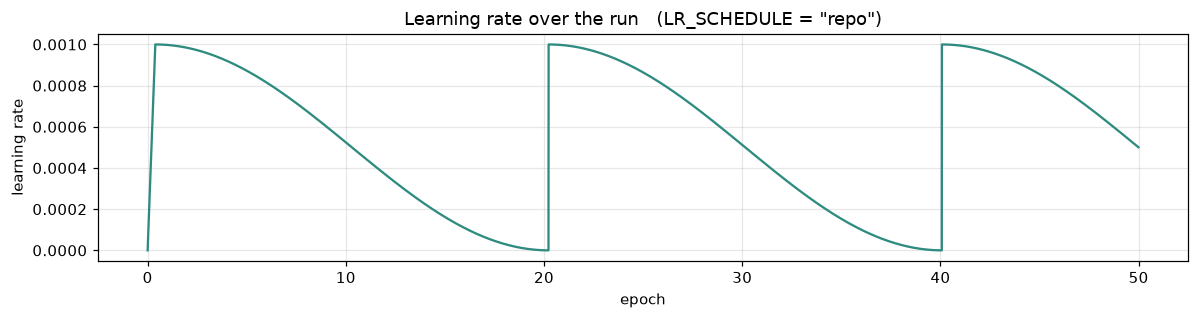

129 weight updates per epoch, 6,450 in total. Learning rate at the end: 5.0e-04


In [14]:
def schedule_lengths(n_batches):
    """(planned length of the curve, number of cosine waves, real weight updates per epoch)."""
    updates_per_epoch = math.ceil(n_batches / ACCUM_STEPS)
    cycles = max(1, EPOCHS // 10)
    planned = n_batches * EPOCHS if LR_SCHEDULE == "repo" else updates_per_epoch * EPOCHS
    return planned, cycles, updates_per_epoch

# Draw the curve this run will follow.
_n_batches = math.ceil(n_per * (len(ALL_SUBJECTS) - len(FOLDS[0])) / BATCH_SIZE) if not SMOKE_TEST else 4
_planned, _cycles, _upe = schedule_lengths(_n_batches)
_opt = torch.optim.AdamW([torch.nn.Parameter(torch.zeros(1))], lr=LR)
_sch = make_lr_schedule(_opt, WARMUP_STEPS, _planned, _cycles)
_curve = []
for _ in range(_upe * EPOCHS):
    _curve.append(_sch.get_last_lr()[0]); _opt.step(); _sch.step()

plt.figure(figsize=(11, 3))
plt.plot(np.arange(len(_curve)) / _upe, _curve, color="#2E8B80", lw=1.5)
plt.xlabel("epoch"); plt.ylabel("learning rate"); plt.grid(alpha=0.3)
plt.title(f'Learning rate over the run   (LR_SCHEDULE = "{LR_SCHEDULE}")')
plt.tight_layout(); plt.show()
print(f"{_upe} weight updates per epoch, {_upe * EPOCHS:,} in total. Learning rate at the end: {_curve[-1]:.1e}")

## Step 9 - Scoring helpers

Two scores, both computed per volume and then averaged, as in the repo's `inference.ipynb`:

- **SSIM** (structural similarity), 0 to 1, higher is better. Compares local patterns of
  brightness and contrast. This is the paper's headline number.
- **PSNR** (peak signal-to-noise ratio), in decibels, higher is better. A log-scaled version of
  the mean squared error.

In [15]:
@torch.no_grad()
def predict(model, rows, batch_size=16, eeg_rows=None):
    """Run the model over the given rows. Returns predictions on the CPU, shape (n, 30, 64, 64).
    `eeg_rows` lets us deliberately feed the EEG of DIFFERENT rows (used for a control test later)."""
    model.eval()
    src = rows if eeg_rows is None else eeg_rows
    out = []
    for s in range(0, len(src), batch_size):
        eeg = normalise_eeg(EEG_ALL[src[s : s + batch_size]].to(DEVICE))
        out.append(model(eeg).float().cpu())
    return torch.cat(out)


@torch.no_grad()
def score_volumes(pred, target, chunk=64):
    """Per-volume SSIM and PSNR. pred and target: (n, 30, 64, 64). Returns two arrays of length n."""
    ssim, psnr = [], []
    for s in range(0, len(pred), chunk):
        p, t = pred[s : s + chunk].to(DEVICE), target[s : s + chunk].to(DEVICE)
        ssim.append(structural_similarity_index_measure(p, t, data_range=1.0, reduction="none").cpu())
        mse = ((p - t) ** 2).flatten(1).mean(1)
        rng = t.flatten(1).max(1).values - t.flatten(1).min(1).values        # 1.0 for our targets
        psnr.append((10 * torch.log10(rng ** 2 / mse)).cpu())
    return torch.cat(ssim).numpy(), torch.cat(psnr).numpy()


@torch.no_grad()
def epoch_test_ssim(model, test_batches):
    """The quick per-epoch score, computed the way the repo's training script does:
    SSIM of each batch of 16, averaged over batches."""
    model.eval()
    vals = [structural_similarity_index_measure(model(eeg), fmri, data_range=1.0).item() for eeg, fmri in test_batches]
    return float(np.mean(vals))

## Step 10 - TRAINING

**This is the long cell.** Everything above takes seconds; this takes hours.

For each fold it:

1. splits the people: the fold's test subject(s) are hidden, everyone else trains
2. builds a fresh model
3. for each epoch: one pass over the training pairs, then a quick score on the hidden person
4. saves after every epoch, so an interrupted run can continue (`RESUME = True`)

Files written to `runs/test_<subject>/`:

| file | what |
|---|---|
| `best_model.pth` | weights from the epoch with the best test SSIM (repo-compatible format) |
| `final_model.pth` | weights after the last epoch |
| `last.pt` | everything needed to resume |
| `history.json` | loss, learning rate and SSIM for every epoch |
| `config.json` | the settings used |

You can leave it running. One line is printed per epoch.

In [ ]:
def run_fold(test_subjects):
    train_subjects = [s for s in ALL_SUBJECTS if s not in test_subjects]
    assert all(s in ALL_SUBJECTS for s in test_subjects), f"{test_subjects} not all in {ALL_SUBJECTS}"
    assert train_subjects, "No training subjects left."

    train_rows, test_rows = rows_of(train_subjects), rows_of(test_subjects)
    if SMOKE_TEST:                                   # a handful of examples only
        train_rows, test_rows = train_rows[:8], test_rows[:6]

    fold_dir = RUN_DIR / ("test_" + "-".join(test_subjects))
    fold_dir.mkdir(parents=True, exist_ok=True)

    # Same seed -> same starting weights and same shuffling order every time.
    # (The repo defines a --seed option but never applies it; we do, so runs can be repeated.)
    torch.manual_seed(SEED); np.random.seed(SEED)
    model = build_model()
    train_batches = Batches(train_rows, BATCH_SIZE, shuffle=True, seed=SEED)
    test_batches  = Batches(test_rows,  BATCH_SIZE, shuffle=False)

    planned, cycles, _ = schedule_lengths(len(train_batches))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)          # weight decay 0.01 (AdamW default)
    scheduler = make_lr_schedule(optimizer, WARMUP_STEPS, planned, cycles)

    history = {"epoch": [], "train_loss": [], "lr": [], "test_ssim": [], "seconds": []}
    best_ssim, best_epoch, start_epoch = -1.0, -1, 0

    # ----- continue an interrupted run -----
    last_path = fold_dir / "last.pt"
    if RESUME and last_path.exists():
        state = torch.load(last_path, map_location=DEVICE)
        model.load_state_dict(state["model"]); optimizer.load_state_dict(state["optimizer"])
        scheduler.load_state_dict(state["scheduler"]); train_batches.rng.set_state(state["shuffle_rng"])
        history, best_ssim, best_epoch = state["history"], state["best_ssim"], state["best_epoch"]
        start_epoch = state["epoch"] + 1
        print(f"Resuming {fold_dir.name} from epoch {start_epoch + 1} (best SSIM so far {best_ssim:.4f})")

    config = dict(test_subjects=test_subjects, train_subjects=train_subjects, epochs=EPOCHS, batch_size=BATCH_SIZE,
                  accum_steps=ACCUM_STEPS, lr=LR, warmup_steps=WARMUP_STEPS, seed=SEED, lr_schedule=LR_SCHEDULE,
                  scan_backend=SCAN_BACKEND, grad_checkpoint=bool(GRAD_CHECKPOINT), fast_attention=FAST_ATTENTION,
                  eeg_min=EEG_MIN, eeg_max=EEG_MAX, n_train=len(train_rows), n_test=len(test_rows),
                  torch=torch.__version__, smoke_test=SMOKE_TEST)
    (fold_dir / "config.json").write_text(json.dumps(config, indent=2))

    print(f"Fold {fold_dir.name}:  train on {len(train_subjects)} subjects ({len(train_rows):,} pairs), "
          f"test on {test_subjects} ({len(test_rows)} pairs), {len(train_batches)} batches per epoch")
    print(f"{'epoch':>6}{'train loss':>12}{'test SSIM':>11}{'best':>9}{'lr':>10}{'min':>7}   remaining")

    def progress(idx, n, loss, lr):                       # a sign of life during the very first epoch
        if epoch == start_epoch and idx in (9, 49) and not SMOKE_TEST:
            print(f"        ... batch {idx+1}/{n}, loss {loss:.4f}")

    for epoch in range(start_epoch, EPOCHS):
        t0 = time.time()
        losses, lrs = train_one_epoch(model, optimizer, scheduler, train_batches, ACCUM_STEPS, on_step=progress)
        ssim_now = epoch_test_ssim(model, test_batches)
        took = time.time() - t0

        history["epoch"].append(epoch + 1);  history["train_loss"].append(float(np.mean(losses)))
        history["lr"].append(lrs[-1]);       history["test_ssim"].append(ssim_now); history["seconds"].append(took)

        is_best = ssim_now > best_ssim
        if is_best:
            best_ssim, best_epoch = ssim_now, epoch + 1
            torch.save(model.state_dict(), fold_dir / "best_model.pth")
        if (epoch + 1) % SAVE_EVERY == 0:
            torch.save(model.state_dict(), fold_dir / f"epoch_{epoch+1:03d}.pth")

        torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(), "scheduler": scheduler.state_dict(),
                    "shuffle_rng": train_batches.rng.get_state(), "history": history, "best_ssim": best_ssim,
                    "best_epoch": best_epoch, "epoch": epoch}, last_path)
        (fold_dir / "history.json").write_text(json.dumps(history, indent=2))

        left = (EPOCHS - epoch - 1) * float(np.mean(history["seconds"])) / 60
        print(f"{epoch+1:>6}{history['train_loss'][-1]:>12.4f}{ssim_now:>11.4f}{best_ssim:>9.4f}{lrs[-1]:>10.1e}"
              f"{took/60:>7.1f}   {left/60:.1f} h" + ("   *best" if is_best else ""))

    torch.save(model.state_dict(), fold_dir / "final_model.pth")
    print(f"Done. Best test SSIM {best_ssim:.4f} at epoch {best_epoch}. Saved in {fold_dir}\n")
    return fold_dir


FOLD_DIRS = []
for fold in FOLDS:
    FOLD_DIRS.append(run_fold(fold))

Fold test_44:  train on 15 subjects (4,110 pairs), test on ['44'] (274 pairs), 257 batches per epoch
 epoch  train loss  test SSIM     best        lr    min   remaining
        ... batch 10/257, loss 0.6779
        ... batch 50/257, loss 0.5366


## Step 11 - Training curves

What to look for:

- **training loss** should fall, with a bump after each learning-rate restart
- **test SSIM** should rise early and then flatten. If it flattens within the first few epochs
  while the training loss keeps falling, the model is memorising the training people instead of
  learning something that transfers to a new person

In [ ]:
def plot_history(fold_dir):
    h = json.loads((fold_dir / "history.json").read_text())
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
    ax[0].plot(h["epoch"], h["train_loss"], color="#BE3B49", marker="o", ms=3); ax[0].set_title("training loss (lower is better)")
    ax[1].plot(h["epoch"], h["test_ssim"], color="#2E8B80", marker="o", ms=3);  ax[1].set_title("SSIM on the hidden subject (higher is better)")
    best = int(np.argmax(h["test_ssim"]))
    ax[1].scatter([h["epoch"][best]], [h["test_ssim"][best]], color="#E0972F", zorder=5, s=60, label=f"best: {h['test_ssim'][best]:.4f}")
    ax[1].legend()
    ax[2].plot(h["epoch"], h["lr"], color="#6B6F85", marker="o", ms=3);         ax[2].set_title("learning rate at the end of each epoch")
    for a in ax: a.set_xlabel("epoch"); a.grid(alpha=0.3)
    fig.suptitle(fold_dir.name, y=1.03); plt.tight_layout(); plt.show()

for d in FOLD_DIRS:
    plot_history(d)

## Step 12 - Evaluation: how good is it, and is it really using the EEG?

A single SSIM number is easy to misread on this task, because every brain looks a lot like every
other brain. A model can score well by drawing a generic brain and ignoring its input. So next
to the model's score we compute **three reference scores**. They cost seconds and turn one
number into an answer.

| row | what is predicted | what it tells you |
|---|---|---|
| **model (best epoch)** | the trained model, best checkpoint | the number comparable to the paper |
| model (last epoch) | the trained model after the final epoch | the score with no peeking - see below |
| **average training brain** | the same volume every time: the mean of all training volumes | the score you get for knowing only what brains look like, with no EEG at all |
| this person's own average | the mean of the test person's own volumes | the best any prediction can do if it never changes over time |
| **model, wrong EEG** | the model fed the same person's EEG from about 5 minutes away | if this scores the same as the real model, the model is not using the timing of the EEG |

**How to read it.** The gap between *model* and *average training brain* is what the EEG (plus
the network) adds beyond a generic brain. The gap between *model* and *model, wrong EEG* is how
much the model depends on the EEG belonging to that exact moment.

**About "best epoch".** The repo keeps the checkpoint with the highest SSIM *on the test
subject*. That means the test data helped choose the model, so the best-epoch score is slightly
optimistic. It is the paper's protocol, so we report it - and the last-epoch score beside it.

The last column, **tracking**, asks a sharper question than SSIM: for each brain voxel, does the
predicted signal go up and down over time when the real one does? It is the correlation between
predicted and real time-courses, taken over the 274 test volumes, median over brain voxels.
0 means no relationship, 1 means perfect.

In [ ]:
def voxel_tracking(pred, target, brain):
    """Median over brain voxels of the correlation, across time, between predicted and real signal."""
    p = pred[:, brain].double();  t = target[:, brain].double()          # (time, n_voxels)
    p = p - p.mean(0);            t = t - t.mean(0)
    r = (p * t).sum(0) / (p.norm(dim=0) * t.norm(dim=0) + 1e-12)
    return float(r.median())


def evaluate_fold(fold_dir):
    cfg = json.loads((fold_dir / "config.json").read_text())
    test_rows, train_rows = rows_of(cfg["test_subjects"]), rows_of(cfg["train_subjects"])
    if cfg["smoke_test"]:
        train_rows, test_rows = train_rows[:8], test_rows[:6]
    target = FMRI_ALL[test_rows]                                            # (n, 30, 64, 64)
    n = len(test_rows)

    model = build_model()
    preds = {}
    for label, fname in [("model (best epoch)", "best_model.pth"), ("model (last epoch)", "final_model.pth")]:
        model.load_state_dict(torch.load(fold_dir / fname, map_location=DEVICE))
        preds[label] = predict(model, test_rows)

    # reference 1: one fixed volume, the average of everything the model trained on
    train_mean = torch.zeros(FMRI_ALL.shape[1:], dtype=torch.float64)
    for s in range(0, len(train_rows), 512):
        train_mean += FMRI_ALL[train_rows[s : s + 512]].double().sum(0)
    preds["average training brain"] = (train_mean / len(train_rows)).float().expand(n, -1, -1, -1)

    # reference 2: the test person's own average volume
    preds["this person's own average"] = target.mean(0, keepdim=True).expand(n, -1, -1, -1)

    # control: best model, but the EEG comes from half the recording away (same person, wrong moment)
    model.load_state_dict(torch.load(fold_dir / "best_model.pth", map_location=DEVICE))
    preds["model, wrong EEG"] = predict(model, test_rows, eeg_rows=torch.roll(test_rows, n // 2))

    brain = target.mean(0) > 0.15                                           # voxels inside the head
    results = {}
    print(f"\n{fold_dir.name}   ({n} test volumes, {int(brain.sum()):,} brain voxels)")
    print(f"{'':<28}{'SSIM':>16}{'PSNR (dB)':>16}{'tracking':>11}")
    print("-" * 71)
    for label, p in preds.items():
        ssim, psnr = score_volumes(p, target)
        constant = "average" in label                                       # a fixed picture cannot track anything
        track = float("nan") if constant else voxel_tracking(p, target, brain)
        results[label] = dict(ssim_mean=float(ssim.mean()), ssim_std=float(ssim.std()),
                              psnr_mean=float(psnr.mean()), psnr_std=float(psnr.std()), tracking=track)
        print(f"{label:<28}{ssim.mean():>9.4f} ± {ssim.std():.3f}{psnr.mean():>9.2f} ± {psnr.std():.2f}"
              + (f"{'-':>11}" if constant else f"{track:>11.3f}"))
    print("-" * 71)
    gain = results["model (best epoch)"]["ssim_mean"] - results["average training brain"]["ssim_mean"]
    drop = results["model (best epoch)"]["ssim_mean"] - results["model, wrong EEG"]["ssim_mean"]
    print(f"SSIM gained over a generic brain          : {gain:+.4f}")
    print(f"SSIM lost when the EEG is from the wrong moment : {drop:+.4f}")

    (fold_dir / "results.json").write_text(json.dumps(results, indent=2))
    return preds, target, results

EVAL = {d.name: evaluate_fold(d) for d in FOLD_DIRS}

### Look at the predictions

Top row: the real scan. Middle: the model's drawing. Bottom: where they differ (brighter =
bigger error).

In [ ]:
def show_prediction(fold_dir, volume=None):
    preds, target, _ = EVAL[fold_dir.name]
    pred = preds["model (best epoch)"]
    volume = len(target) // 2 if volume is None else volume
    slices = [4, 9, 14, 19, 24, 28]

    fig, axes = plt.subplots(3, len(slices), figsize=(2.3 * len(slices), 7))
    for j, z in enumerate(slices):
        real, drawn = target[volume, z].numpy(), pred[volume, z].numpy()
        axes[0, j].imshow(np.rot90(real),  cmap="gray", vmin=0, vmax=1); axes[0, j].set_title(f"slice {z+1}", fontsize=9)
        axes[1, j].imshow(np.rot90(drawn), cmap="gray", vmin=0, vmax=1)
        axes[2, j].imshow(np.rot90(np.abs(real - drawn)), cmap="magma", vmin=0, vmax=0.3)
    for ax in axes.ravel(): ax.set_xticks([]); ax.set_yticks([])
    axes[0, 0].set_ylabel("real scan"); axes[1, 0].set_ylabel("model"); axes[2, 0].set_ylabel("|difference|")
    fig.suptitle(f"{fold_dir.name} - test volume {volume}", y=0.99); plt.tight_layout(); plt.show()

    # The same test, seen over time: a few voxels, real signal against predicted signal.
    brain = target.mean(0) > 0.15
    zz, xx, yy = np.nonzero(brain.numpy())
    pick = np.linspace(0, len(zz) - 1, 5).astype(int)[1:4]                  # three voxels spread through the brain
    fig, axes = plt.subplots(1, 3, figsize=(15, 2.8))
    for ax, k in zip(axes, pick):
        z, x, y = zz[k], xx[k], yy[k]
        ax.plot(target[:, z, x, y].numpy(), color="black", lw=1, label="real")
        ax.plot(pred[:, z, x, y].numpy(), color="#BE3B49", lw=1, label="model")
        ax.set_title(f"voxel (slice {z+1}, {x}, {y}) over time", fontsize=9); ax.set_xlabel("test volume"); ax.grid(alpha=0.3)
    axes[0].legend(); plt.tight_layout(); plt.show()

for d in FOLD_DIRS:
    show_prediction(d)

## Step 13 - Summary, and running all 16 folds

The paper's NODDI result is an average over leave-one-subject-out folds:
**SSIM 0.693 ± 0.048** (and PSNR 20.80 dB), against 0.605 for the earlier E2fNet model.
A single fold can easily sit 0.05 above or below that average, so one fold is a sanity check,
not a replication.

To run the full protocol, set this in Step 2 and re-run the notebook:

```python
FOLDS = "all"        # one fold per subject: [["32"], ["35"], ..., ["50"]]
```

or list just the folds you want, for example `FOLDS = [["44"], ["49"], ["32"]]`. A fold that
already finished is not trained again (`RESUME = True`), so you can add folds over several days.

The cell below collects every finished fold found in the run folder.

In [ ]:
rows = []
for res_path in sorted(RUN_DIR.glob("test_*/results.json")):
    r = json.loads(res_path.read_text())
    rows.append((res_path.parent.name.replace("test_", ""), r))

if rows:
    keys = ["model (best epoch)", "model (last epoch)", "average training brain", "model, wrong EEG"]
    print(f"{'test subject':<14}" + "".join(f"{k:>26}" for k in keys))
    print("-" * (14 + 26 * len(keys)))
    for name, r in rows:
        print(f"{name:<14}" + "".join(f"{r[k]['ssim_mean']:>26.4f}" for k in keys))
    print("-" * (14 + 26 * len(keys)))
    if len(rows) > 1:
        print(f"{'mean':<14}" + "".join(f"{np.mean([r[k]['ssim_mean'] for _, r in rows]):>26.4f}" for k in keys))
        print(f"{'std over folds':<14}" + "".join(f"{np.std([r[k]['ssim_mean'] for _, r in rows]):>26.4f}" for k in keys))
    print(f"\n{len(rows)} fold(s) finished.  Paper, 16-fold average: SSIM 0.693 ± 0.048")
else:
    print("No finished folds yet.")

## What to write in a report

**Method, in one paragraph.** EEG recorded at 250 Hz on 64 channels is cut into non-overlapping
2.16 s windows aligned to the fMRI volumes. Each window is converted to an FFT magnitude spectrum
(249 bins, 0.46 to 115.3 Hz), z-scored across channels, and min-max scaled to 0-1 with a global
minimum and maximum. Twenty consecutive windows (43.2 s) form the input `(20, 64, 249)`. The
target is the next fMRI volume `(30, 64, 64)`, min-max scaled per volume. Spec2VolCAMU-Net
(45.9 M parameters: a convolution-plus-attention encoder and a Vision-Mamba U-Net decoder) is
trained with AdamW (learning rate 1e-3, weight decay 0.01), batch 16 with 2-step gradient
accumulation, gradient clipping at 1.0, cosine learning-rate schedule with warm-up and hard
restarts, for 50 epochs, minimising 0.5 (1 - SSIM) + 0.5 MSE. Evaluation is leave-one-subject-out.

**Results.** Report the table from Step 12, not just the top row. The honest headline is the
*gain over the average training brain*, with the wrong-EEG control beside it.

**Limitations worth stating** (all found by reading the code):

- the best checkpoint is chosen using the test subject (optimistic)
- the global EEG min/max is computed over train and test subjects together
- one of the 64 "EEG" channels is an ECG channel and takes part in the z-score
- the network's "time" operations actually act on frequency bins and channels (Step 6 note)
- the learning-rate schedule in the code differs from the one described in the paper (Step 8)
- targets are scaled per volume, which removes slow global signal changes and makes the empty
  background (about 60% of each volume) trivially predictable